In [1]:
import numpy as np
import pandas as pd
import psycopg as pg
import mlflow
import os
from catboost import CatBoostClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt

In [2]:
TABLE_NAME = "clean_users_churn"
TACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

EXPERIMENT_NAME = "SFS_analyzing"
RUN_NAME = "feature_selection"
REGISTRY_MODEL_NAME = "SFS_MODEL"
FS_ASSETS = "fs_assets"

In [3]:
configs = {"sslmode": "require", "target_session_attrs": "read-write"}
db_credits = {
    "host": os.getenv("DB_DESTINATION_HOST"),
    "port": os.getenv("DB_DESTINATION_PORT"),
    "dbname": os.getenv("DB_DESTINATION_NAME"),
    "user": os.getenv("DB_DESTINATION_USER"),
    "password": os.getenv("DB_DESTINATION_PASSWORD")
}

configs.update(db_credits)

In [4]:
with pg.connect(**configs) as conn:
    with conn.cursor() as cur:
        cur.execute(f"SELECT * FROM {TABLE_NAME}")

        data = cur.fetchall()

        columns = [col.name for col in cur.description]

In [5]:
df = pd.DataFrame(data=data, columns=columns)

In [6]:
df.head(3)

,id,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,gender,senior_citizen,partner,dependents,multiple_lines,target
0,28,1680-VDCWW,2019-02-01,NaT,One year,No,Bank transfer (automatic),19.80,202.25,Fiber optic,...,No,No,No,No,Male,0,Yes,No,No,0
1,29,1066-JKSGK,2019-11-01,2019-12-01,Month-to-month,No,Mailed check,20.15,20.15,Fiber optic,...,No,No,No,No,Male,0,No,No,No,1
2,30,3638-WEABW,2015-04-01,NaT,Two year,Yes,Credit card (automatic),59.90,3505.10,DSL,...,No,Yes,No,No,Female,0,Yes,No,Yes,0


In [7]:
df.columns

Index(['id', 'customer_id', 'begin_date', 'end_date', 'type',
       'paperless_billing', 'payment_method', 'monthly_charges',
       'total_charges', 'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'gender', 'senior_citizen', 'partner', 'dependents', 'multiple_lines',
       'target'],
      dtype='object')

In [8]:
X = df.drop(columns=["id", "customer_id", "begin_date", "end_date", "target"])
y = df["target"]

In [9]:
num_columns = ["monthly_charges", "total_charges"]
cat_columns = ["type", "payment_method", "internet_service", "gender"]


In [10]:
binary_obj_cols = X.drop(columns=cat_columns+num_columns)

In [11]:
binary_obj_cols = binary_obj_cols.replace({"Yes": 1, "No": 0})

In [12]:
encoder_oh = OneHotEncoder(categories="auto", handle_unknown="error", max_categories=15, drop="first", sparse_output=False)

In [13]:
categorical_transformer = encoder_oh.fit_transform(X[cat_columns])

In [14]:
cat_transformed_df = pd.DataFrame(categorical_transformer, columns=encoder_oh.get_feature_names_out())

In [15]:
scaler = StandardScaler()

In [16]:
X[num_columns] = scaler.fit_transform(X[num_columns])

In [17]:
transformed_df = pd.concat([X[num_columns], cat_transformed_df, binary_obj_cols], axis=1)

In [18]:
X = transformed_df.values
y = y.values

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
estimator = RandomForestClassifier(n_estimators=300, random_state=42)

In [21]:
sfs = SFS(estimator, k_features=10, forward=True, floating=False, scoring='roc_auc', cv=4)
sbs = SFS(estimator, k_features=10, forward=False, floating=False, scoring='roc_auc', cv=4)

In [22]:
sfs = sfs.fit(X_train, y_train)
sbs = sbs.fit(X_train, y_train)

In [39]:
selected_features_sfs = X_train[:, sfs.k_feature_idx_]
selected_features_sbs = X_train[:, sbs.k_feature_idx_]

In [40]:
selected_features = list(set(sbs.k_feature_idx_).union(set(sbs.k_feature_idx_)))

In [41]:
selected_features

[0, 1, 2, 3, 5, 7, 9, 10, 13, 15]

In [42]:
X_train_selected = X_train[:, selected_features]

In [49]:
sbs.k_score_

0.816989123749081

In [48]:
sfs.k_score_

0.7906743698152541

In [56]:
sfs_df = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
sbs_df = pd.DataFrame.from_dict(sbs.get_metric_dict()).T

In [58]:
os.mkdir(FS_ASSETS)
sfs_df.to_csv(f"{FS_ASSETS}/sfs.csv")
sbs_df.to_csv(f"{FS_ASSETS}/sbs.csv")

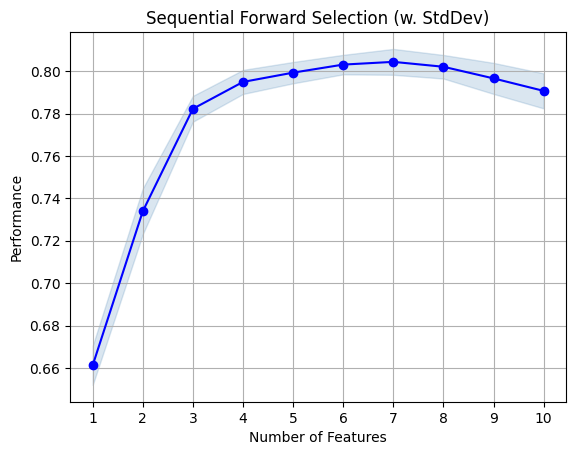

In [62]:
fig1 = plot_sfs(sfs.get_metric_dict(), kind='std_dev')
plt.title("Sequential Forward Selection (w. StdDev)")
plt.grid()
plt.show()

In [61]:
plt.savefig(f"{FS_ASSETS}/sfs.png")

<Figure size 640x480 with 0 Axes>

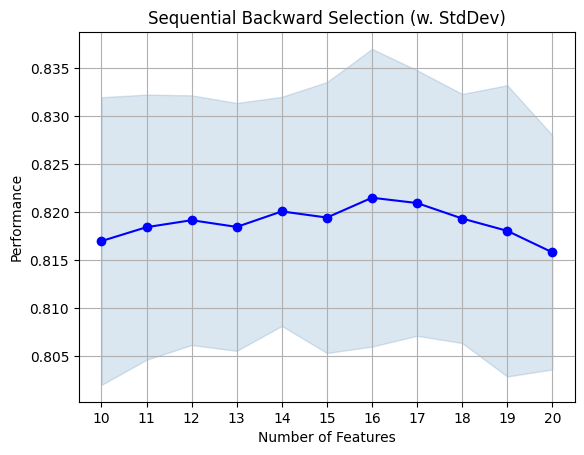

In [63]:
fig2 = plot_sfs(sbs.get_metric_dict(), kind='std_dev')
plt.title("Sequential Backward Selection (w. StdDev)")
plt.grid()
plt.show()

In [64]:
plt.savefig(f"{FS_ASSETS}/sbs.png")

<Figure size 640x480 with 0 Axes>

In [68]:
top_sfs = sfs.k_feature_names_
top_sbs = sbs.k_feature_names_

In [71]:
interc_features = list(set(top_sfs) & set(top_sbs))
union_features = list(set(top_sbs) | set(top_sfs))

In [72]:
interc_features

['5', '2', '15', '7', '9', '3']

In [73]:
union_features

['5', '2', '4', '15', '13', '16', '7', '9', '0', '1', '11', '6', '3', '10']